<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/Fashion_Product_Image_Classifier_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛍 Scenario: Fashion Product Image Classifier
You are working as an AI Engineer for an e-commerce company.
The company wants to automatically classify clothing products from images into categories such as:
T-shirt
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot
The dataset contains 28×28 grayscale images of fashion items.
Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

Task 1 — Dataset Exploration
Load the Fashion-MNIST dataset and perform basic inspection.
Students must:
Load dataset using TensorFlow/Keras
Print:
Number of training images
Number of testing images
Display 10 random images with their labels
Goal:

Understand the dataset visually.
Task 2 — Data Preprocessing
Prepare the dataset for CNN training.
Students must:
Normalize pixel values (0–255 → 0–1)
Reshape images to CNN format
Expected shape:
(28, 28, 1)
Also convert labels to one-hot encoding.

Task 3 — Visualize Class Distribution
Students must:
Count number of images in each class
Plot bar chart of class distribution
Goal:

Check whether the dataset is balanced.

Task 5 — Model Compilation
Students must compile the model using:
Optimizer → Adam
Loss → categorical crossentropy
Metrics → accuracy
Goal:

Understand how models are configured before training.
Task 6 — Train the Model
Train the CNN with:
Epochs = 10
Batch size = 64
Validation split = 20%
Students must:
Plot training accuracy vs validation accuracy
Plot training loss vs validation loss
Goal:

Observe model learning behaviour.

Task 7 — Model Evaluation
Evaluate model performance on test dataset.
Students must print:
Test accuracy
Test loss
Then display 5 test images with predictions.
Goal:

Understand how models generalize to unseen data.
 Task 8 — Confusion Matrix Analysis
Students must:
Generate confusion matrix
Visualize using heatmap
Goal:
Understand which classes are misclassified.
Example challenge:
Shirt vs T-shirt
Sneaker vs Ankle Boot
ask 9 — Improve the CNN Architecture
Students must modify the architecture by:
Adding Dropout layer
Increasing filters
Adding another convolution layer
Example:
Conv → Conv → Pool → Conv → Pool
Then compare:
Model 1 accuracy vs Model 2 accuracy
Goal:
Understand model improvement strategies.
Task 10 — Misclassification Analysis
Students must:
Identify 5 wrongly predicted images
Display:
Actual label
Predicted label
Then explain:
Why might the model confuse these classes?
Goal:

Develop model debugging skills.

Task 11 — Feature Map Visualization
Students must:
Extract intermediate CNN layer outputs
Visualize feature maps for one image
Goal:

Understand what CNN learns internally.
Task 12 — Build Simple Prediction Interface
Students must write code that:
Takes a random test image
Predicts class
Displays predicted label with probability
Goal:

Simulate real-world inference.


In [1]:
from tensorflow.keras.datasets import fashion_mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#Load the dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

#Display dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"x_train shape: {y_train.shape}")
print(f"x_train shape: {x_test.shape}")
print(f"x_train shape: {y_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
x_train shape: (60000,)
x_train shape: (10000, 28, 28)
x_train shape: (10000,)


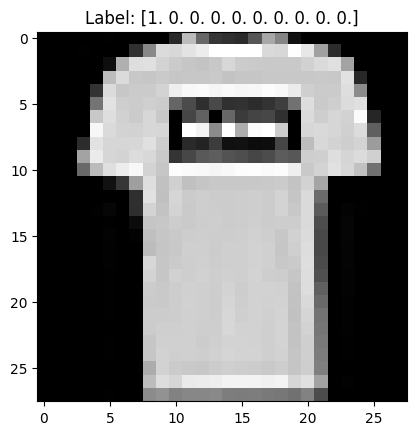

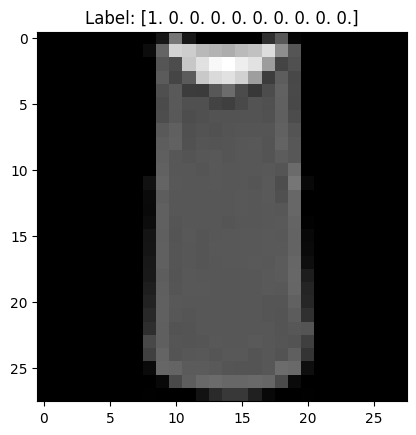

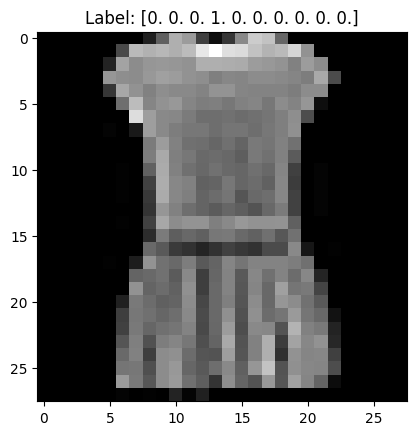

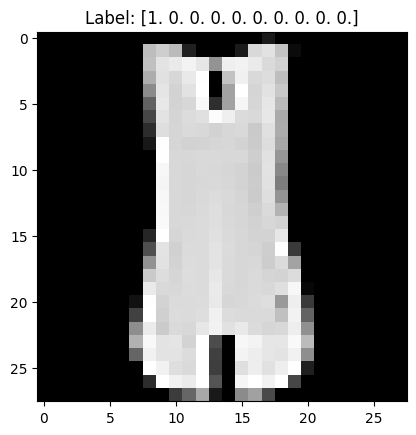

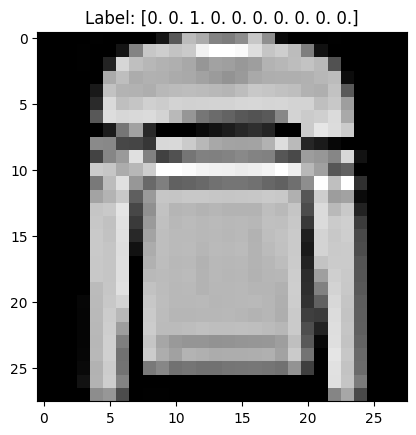

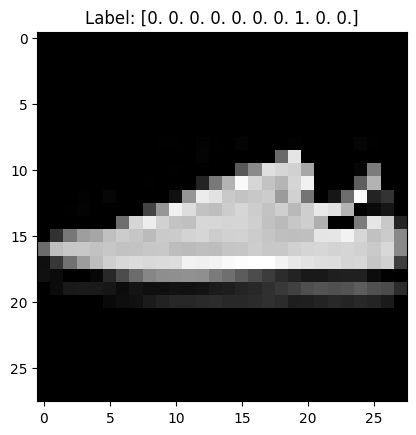

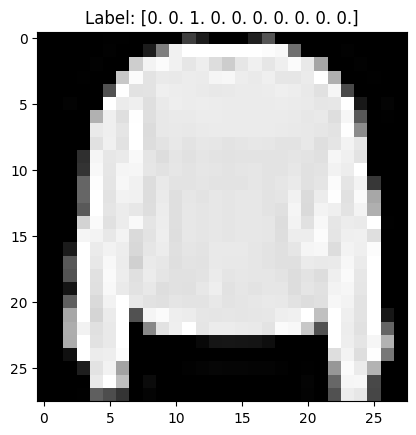

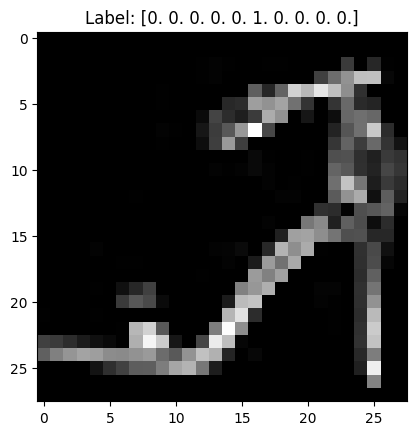

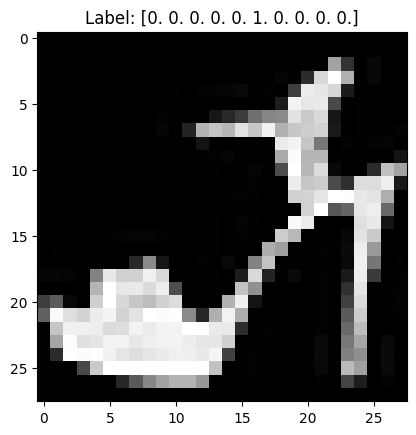

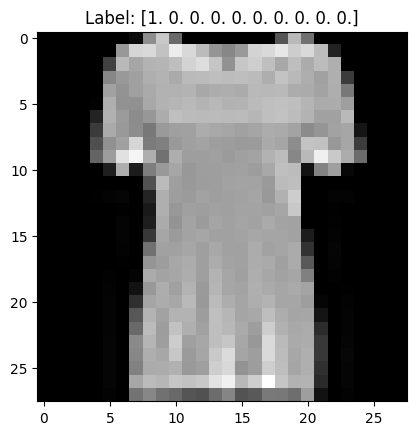

In [15]:
#Basic Data Visualization
for i in range(1,10+1):
  img = x_train[i,:,:]
  label = y_train[i]
  plt.imshow(img, cmap = 'gray')
  plt.title(f"Label: {label}")
  plt.show()

In [6]:
from keras.src.utils import to_categorical
#normalize and reshape
x_train = x_train.reshape(-1,28,28,1).astype('float32')/255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float')/255

#one - hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [7]:
model = Sequential([
    Conv2D(32,kernel_size = (3, 3), activation = 'relu', input_shape = (28, 28, 1)),    #convolution layer - detect patterns
    MaxPooling2D(pool_size=(2, 2)), #Pooling layer - reduces spatial dimensions
    Conv2D(64, kernel_size=(3, 3), activation='relu'), #Convlution layer - detects patterns
    MaxPooling2D(pool_size=(2, 2)), #Pooling layer - reduces spatial dimensions
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(10, activation = 'softmax')
    ])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [12]:

history = model.fit(x_train, y_train, epochs = 10, batch_size = 64, validation_split=0.2)
#epochs -> model sees dataset 5 times
#batch_size -> processes 128 images per step
#validation_split -> uses 20% of training data fro validation

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8953 - loss: 0.2850 - val_accuracy: 0.8924 - val_loss: 0.2949
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9109 - loss: 0.2439 - val_accuracy: 0.9033 - val_loss: 0.2711
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9220 - loss: 0.2122 - val_accuracy: 0.8992 - val_loss: 0.2743
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9265 - loss: 0.1966 - val_accuracy: 0.9109 - val_loss: 0.2495
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9336 - loss: 0.1791 - val_accuracy: 0.9033 - val_loss: 0.2673
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9411 - loss: 0.1611 - val_accuracy: 0.9072 - val_loss: 0.2688
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9458 - loss: 0.1462 - val_accuracy: 0.9086 - val_loss: 0.2769
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9537 - loss: 0.1249 - val_accuracy: 0.

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8781 - loss: 0.3401
Test loss: 0.33465415239334106
Test accuracy: 0.8787999749183655


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step


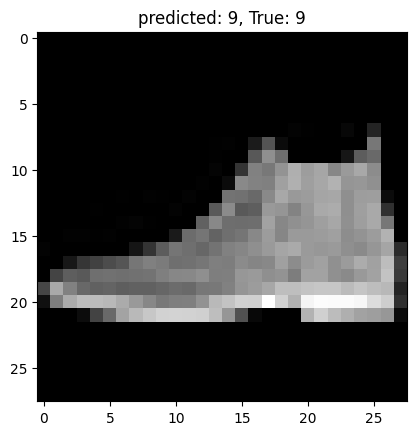

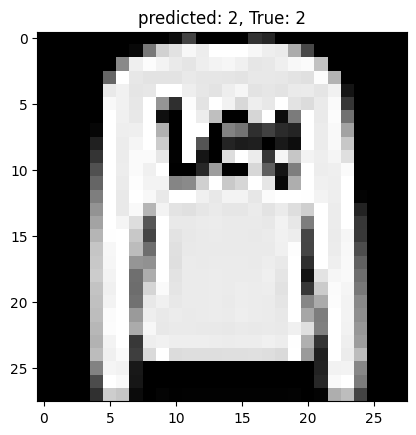

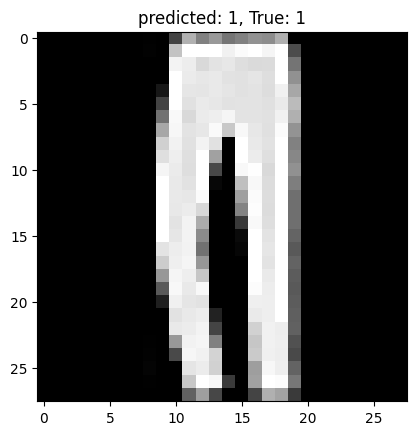

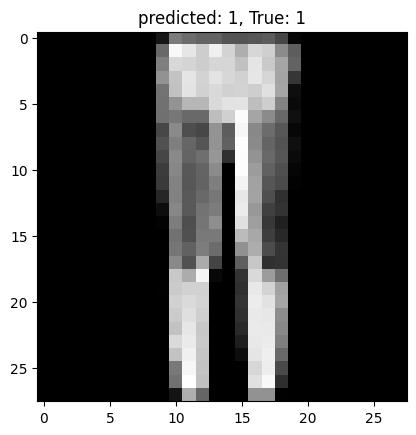

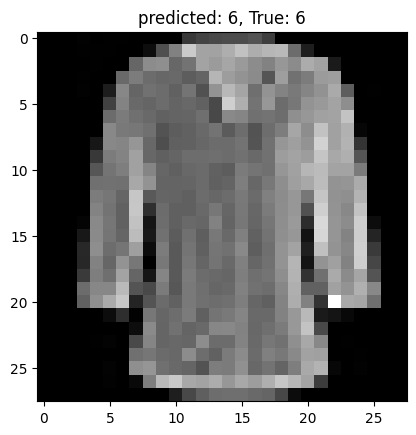

In [11]:
#predict on the few test samples
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = np.argmax(y_test[:5], axis = 1)

for i in range(5):
  plt.imshow(x_test[i].reshape(28, 28), cmap = 'gray')
  plt.title(f"predicted: {predicted_classes[i]}, True: {true_classes[i]}")
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


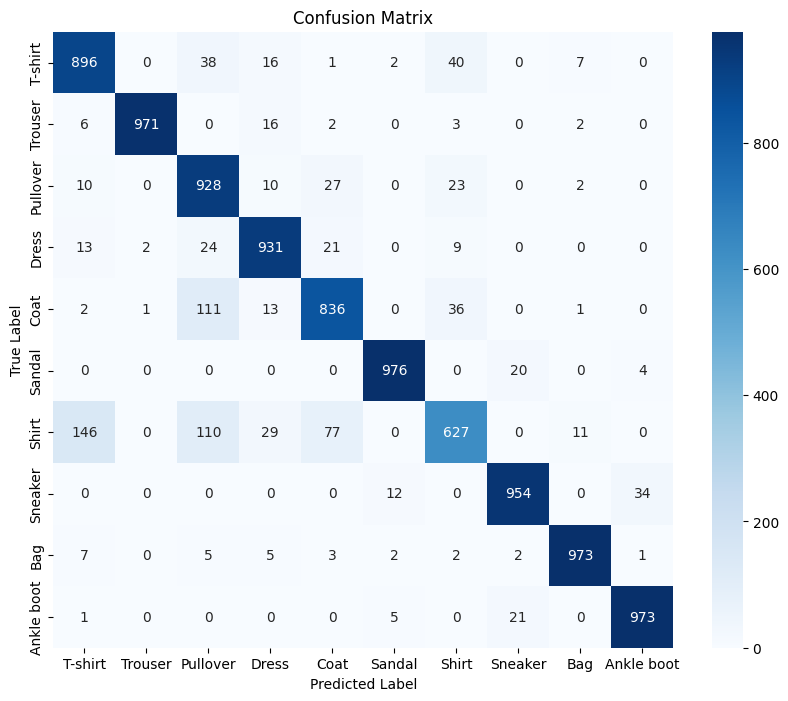

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define class names for Fashion-MNIST
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get predictions for the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from tensorflow.keras.layers import Dropout

model2 = Sequential()

# Conv → Conv → Pool
model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model2.add(Conv2D(32, (3,3), activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Conv → Pool
model2.add(Conv2D(64, (3,3), activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Flatten
model2.add(Flatten())

# Dense
model2.add(Dense(128, activation='relu'))

# Dropout added
model2.add(Dropout(0.5))

# Output
model2.add(Dense(10, activation='softmax'))

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Model 2 Test Accuracy:", test_accuracy2)

test_loss1, test_accuracy1 = model.evaluate(x_test, y_test)

print("Model 1 Accuracy:", test_accuracy1)
print("Model 2 Accuracy:", test_accuracy2)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6822 - loss: 0.8673 - val_accuracy: 0.8540 - val_loss: 0.3912
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8533 - loss: 0.4122 - val_accuracy: 0.8908 - val_loss: 0.2955
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8803 - loss: 0.3321 - val_accuracy: 0.8983 - val_loss: 0.2769
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8945 - loss: 0.2907 - val_accuracy: 0.9039 - val_loss: 0.2567
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9023 - loss: 0.2707 - val_accuracy: 0.9111 - val_loss: 0.2423
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9098 - loss: 0.2431 - val_accuracy: 0.9133 - val_loss: 0.2400
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9165 - loss: 0.2301 - val_accuracy: 0.9173 - val_loss: 0.2259
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9260 - loss: 0.2079 - val_accuracy: 0.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


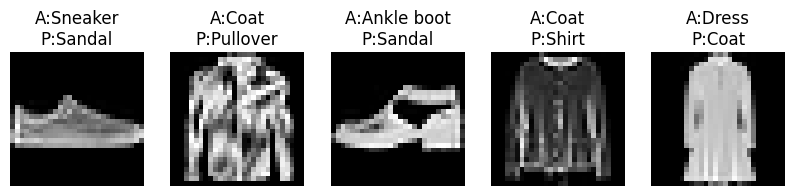

In [24]:
import numpy as np

# Predictions from model
predictions = model2.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# Find indices where prediction is wrong
wrong_indices = np.where(y_pred != y_true)[0]


import matplotlib.pyplot as plt

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))

for i in range(5):
    index = wrong_indices[i]

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')

    actual = class_names[y_true[index]]
    predicted = class_names[y_pred[index]]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

In [30]:
from tensorflow.keras.models import Model

# Select one test image
sample_image = x_test[0].reshape(1,28,28,1)

# Get convolution layer outputs
layer_outputs = [layer.output for layer in model2.layers if 'conv' in layer.name]

# Create feature extraction model
feature_model = Model(inputs=model2.inputs, outputs=layer_outputs)

# Generate feature maps
feature_maps = feature_model.predict(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


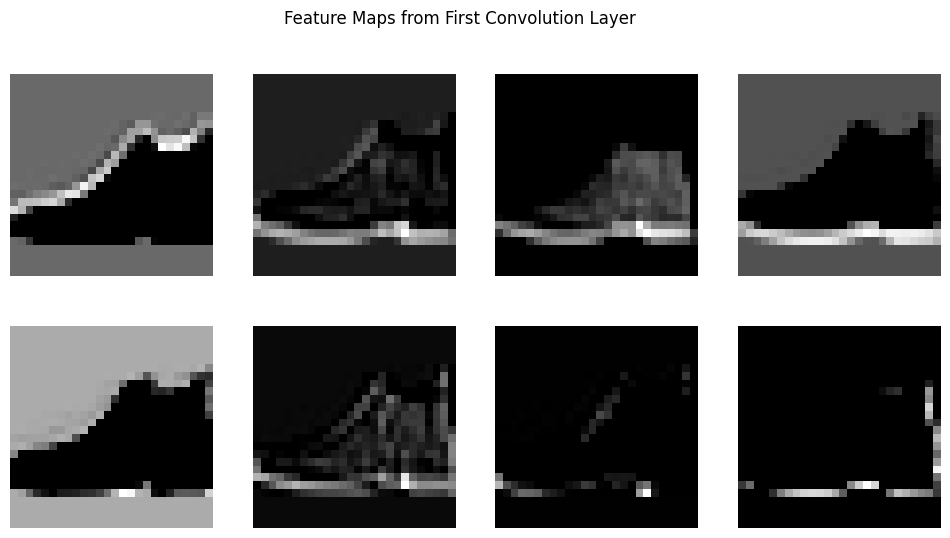

In [31]:
import matplotlib.pyplot as plt

feature_map = feature_maps[0]

plt.figure(figsize=(12,6))

for i in range(8):   # show first 8 filters
    plt.subplot(2,4,i+1)
    plt.imshow(feature_map[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()